# **IMPORTS**

In [1]:
# python imports
import numpy as np

#For Circuit Design
import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, transpile

#For Visualization
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

#For Running the circuit
from qiskit_aer import Aer
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

#Fake Backends
from qiskit_ibm_runtime.fake_provider import FakeBrisbane

In [2]:
import platform
print("Python:", platform.python_version()) 
print("Qiskit:", qiskit.__version__) 
print("Qiskit Aer:", qiskit_aer.__version__)

Python: 3.11.9
Qiskit: 2.4.2
Qiskit Aer: 0.17.2


# **Creating a Quantum Circuit to generate Bell State:**

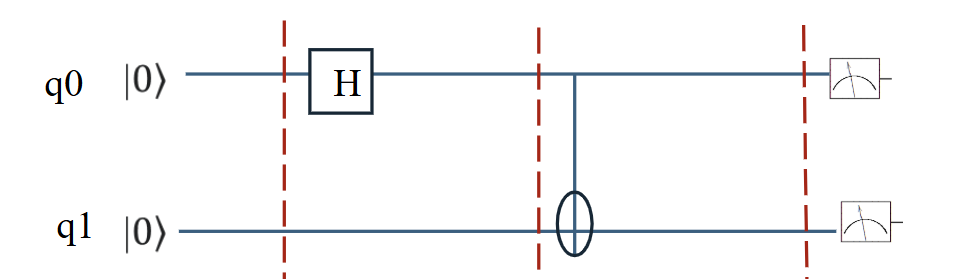

In [3]:
def bell_circuit(measure=False):
    if measure:
        qc = QuantumCircuit(2, 2)
    else:
        qc = QuantumCircuit(2)
        

    qc.h(0)
    qc.cx(0, 1)

    if measure:
        qc.measure([0, 1], [0, 1])

    return qc


# **Running the Circuits through Different Backends**

## **StateVector Simulator**

We now run the circuit through a statevector simulator, and see what states we are getting. A statevector simulator is a classical simulator that generates exact states (wave functions), and not probabilities (physical realization).  

In [4]:
qc_sv = bell_circuit(measure=False)
qc_sv.save_statevector()

backend_sv = AerSimulator(method="statevector")

tqc_sv = transpile(qc_sv, backend_sv, optimization_level=3)
result_sv = backend_sv.run(tqc_sv).result()

statevector = result_sv.data(0)["statevector"]
display(statevector.draw("latex"))

<IPython.core.display.Latex object>

In [5]:
print(f'The vector form of the statevector is {np.asarray(statevector)}')

The vector form of the statevector is [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


## **Mps Simulator**

In [6]:
qc_mps = bell_circuit()
qc_mps.save_matrix_product_state(label="my_mps")
qc_mps.save_statevector(label="my_sv")   # optional: useful for comparison

backend_mps = AerSimulator(method="matrix_product_state")

tqc_mps = transpile(qc_mps, backend_mps, optimization_level=3)
result_mps = backend_mps.run(tqc_mps).result()

data_mps = result_mps.data(0)

mps = data_mps["my_mps"]
sv_from_mps = data_mps["my_sv"]

display(sv_from_mps.draw("latex"))

<IPython.core.display.Latex object>

In [7]:
mps

([(array([[1.-0.j, 0.-0.j]]), array([[0.-0.j, 1.-0.j]])),
  (array([[1.-0.j],
          [0.-0.j]]),
   array([[0.-0.j],
          [1.-0.j]]))],
 [array([0.70710678, 0.70710678])])

In [8]:
type(mps), len(mps)

(tuple, 2)

In [9]:
qc_stab = bell_circuit()
qc_stab.save_stabilizer(label="my_stabilizer")

backend_stab = AerSimulator(method="stabilizer")

tqc_stab = transpile(qc_stab, backend_stab, optimization_level=3)
result_stab = backend_stab.run(tqc_stab).result()

stabilizer_state = result_stab.data(0)["my_stabilizer"]
stabilizer_state

StabilizerState(['+XX', '+ZZ'])

## **Measurement (AER) Simulator**

We will now run the circuit through a simulator (classical) that behaves like a quantum computer. As we cannot realize the wave function itself, and only rely on its probability to visualize it in the classical world, we need to MEASURE. This requires changing the circuit a little bit, i.e., adding classical bits to it, as well as adding measurements to it.

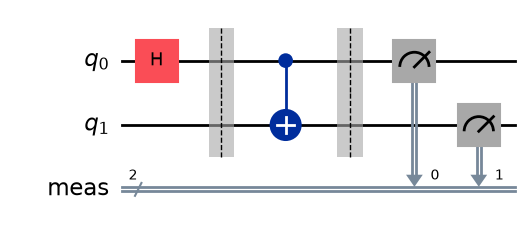

In [10]:
num_qubits=2 #no of qubits in my circuit.

qc = QuantumCircuit(num_qubits)

qc.h(0)
qc.barrier()
qc.cx(0, 1)

qc.measure_all()

qc.draw(output='mpl', idle_wires=False, style="iqp")


In [11]:
shot=10000
backend = AerSimulator()
result = backend.run(qc, shots=shot, optimization_level=3).result()
counts = result.get_counts()
print(f'The counts for each possible basis state is: {counts}')
keys=[i for i in counts.keys()]
probability=[counts[i]/shot for i in keys]
print(f'The probability of state 00 is: {probability[0]} '+f'and state 11 is: {probability[1]}.'
       )

The counts for each possible basis state is: {'00': 5063, '11': 4937}
The probability of state 00 is: 0.5063 and state 11 is: 0.4937.


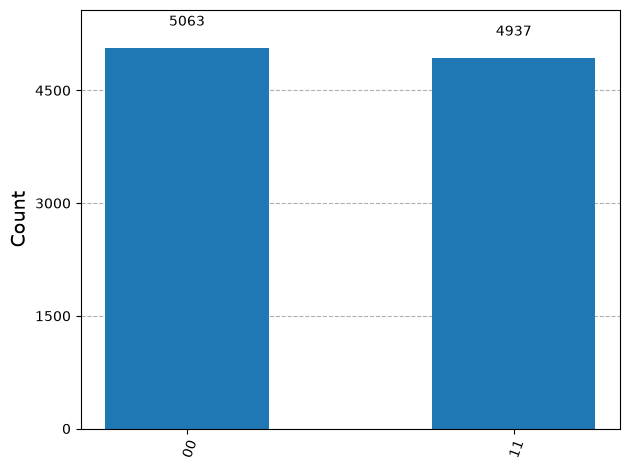

In [12]:
#Visualization
plot_histogram(counts)

## **Fake Backends**

In IBM Quantum, the real quantum hardwares are now not free to use. With the free plan, one can only use a real backend for 10 minutes per month. However, they have created a type of simulators, that mimicks the noises present in the those real Hardware, as well as its architecture. These are called Fake Backends, and they are great for testing your code.

In [13]:
device_backend = FakeBrisbane()
sim_brisbane = AerSimulator.from_backend(device_backend)

***A direct quote from IBMQ Fake Backend documentation ***

"Important: When running noisy simulations it is critical to transpile the circuit for the backend so that the circuit is transpiled to the correct noisy basis gate set for the backend."


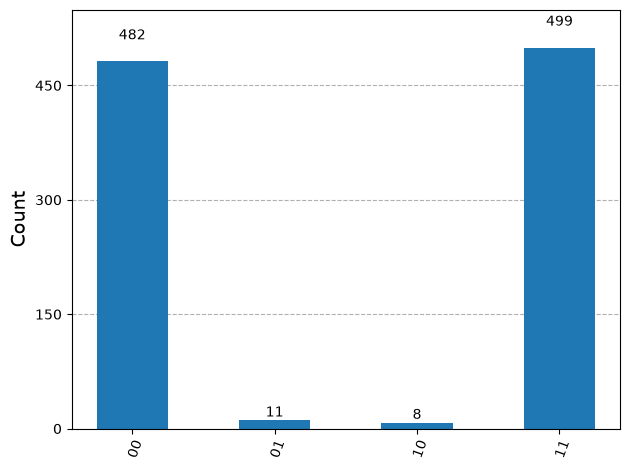

In [14]:
# Transpile the circuit for the noisy basis gates
trans_qc = transpile(qc, sim_brisbane)
shot=1000
# Execute noisy simulation and get counts
result_noise = sim_brisbane.run(trans_qc, shots=shot, optimization_level=3).result()
counts_noise = result_noise.get_counts(0)
plot_histogram(counts_noise)